# Teil 3: Modell berechnen und Vorhersagen machen

In diesem Notebook wird ein Machine-Learning-Modell erstellt, um die Anzahl **Goals** eines Handballspielers vorherzusagen. Als Datensatz wird `LB.xlsx` verwendet. Das Notebook gehört zu Teil 3 der Leistungsbeurteilung LB259.

In [1]:
# Benötigte Bibliotheken importieren
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

## 1. Datensatz laden

Die Excel-Datei `LB.xlsx` muss im gleichen Ordner wie dieses Notebook liegen. Auf GitHub muss diese Datei ebenfalls hochgeladen sein, damit die Lehrperson das Notebook ausführen kann.

In [2]:
# Datensatz laden
df = pd.read_excel("LB.xlsx")

# Erste Kontrolle
display(df.head())
print("Anzahl Zeilen und Spalten:", df.shape)

,Lastname,Name,Team,Position,Games Played,Goals,Missed,Field Goals,Penalty Goals,Shooting Accuracy,Assists,Technical Faults,Steals,Blocks,Yellow Cards,2 Min Exclusion,Red Cards,Blue Cards,Season,Tier
0,Savvas,Savvas,HIL,LB,36,289,195,210,79,5971,52,40,7,7,20,16,1,0,17/18,B
1,Gunnarsson,Arnor Thor,BHC,RW,38,275,93,163,112,7473000000000001,14,17,11,0,2,3,0,0,17/18,B
2,Smits,Kay,WHV,RB,37,258,141,178,80,6466,90,74,20,4,5,10,0,0,17/18,B
3,Kaletsch,Paul,KON,LB,35,251,194,142,109,564,74,62,4,6,13,12,0,0,17/18,B
4,Billek,Florian,COB,RW,37,243,98,132,111,7126,24,29,20,0,4,2,0,0,17/18,B


Anzahl Zeilen und Spalten: (5825, 20)


In [3]:
# Kontrolle der Spalten und fehlenden Werte
display(df.info())
display(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5825 entries, 0 to 5824
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Lastname           5825 non-null   str  
 1   Name               5820 non-null   str  
 2   Team               5825 non-null   str  
 3   Position           5825 non-null   str  
 4   Games Played       5825 non-null   int64
 5   Goals              5825 non-null   int64
 6   Missed             5825 non-null   int64
 7   Field Goals        5825 non-null   int64
 8   Penalty Goals      5825 non-null   int64
 9   Shooting Accuracy  5825 non-null   int64
 10  Assists            5825 non-null   int64
 11  Technical Faults   5825 non-null   int64
 12  Steals             5825 non-null   int64
 13  Blocks             5825 non-null   int64
 14  Yellow Cards       5825 non-null   int64
 15  2 Min Exclusion    5825 non-null   int64
 16  Red Cards          5825 non-null   int64
 17  Blue Cards         5825 n

None

Lastname             0
Name                 5
Team                 0
Position             0
Games Played         0
Goals                0
Missed               0
Field Goals          0
Penalty Goals        0
Shooting Accuracy    0
Assists              0
Technical Faults     0
Steals               0
Blocks               0
Yellow Cards         0
2 Min Exclusion      0
Red Cards            0
Blue Cards           0
Season               0
Tier                 0
dtype: int64

## 2. Zielvariable und Features bestimmen

Die Zielvariable ist **Goals**, also die Anzahl Tore eines Spielers. Diese Spalte soll vom Modell vorhergesagt werden.

Wichtig: Die Spalten **Field Goals** und **Penalty Goals** werden nicht als Features verwendet, weil `Goals = Field Goals + Penalty Goals` gilt. Diese Spalten würden dem Modell die Lösung praktisch direkt verraten. Auch **Shooting Accuracy** wird nicht verwendet, weil die Werte im vorherigen Notebook als unplausibel erkannt wurden.

In [4]:
# Zielvariable
target = "Goals"

# Numerische Features ohne direkte Ziel-Leakage
numeric_features = [
    "Games Played",
    "Missed",
    "Assists",
    "Technical Faults",
    "Steals",
    "Blocks",
    "Yellow Cards",
    "2 Min Exclusion",
    "Red Cards",
    "Blue Cards"
]

# Kategorische Features
categorical_features = [
    "Position",
    "Team",
    "Season",
    "Tier"
]

# Input-Daten und Zielwerte
X = df[numeric_features + categorical_features]
y = df[target]

print("Features:", X.columns.tolist())
print("Zielvariable:", target)

Features: ['Games Played', 'Missed', 'Assists', 'Technical Faults', 'Steals', 'Blocks', 'Yellow Cards', '2 Min Exclusion', 'Red Cards', 'Blue Cards', 'Position', 'Team', 'Season', 'Tier']
Zielvariable: Goals


## 3. Train-Test-Aufteilung

Der Datensatz wird in Trainings- und Testdaten aufgeteilt. Das Modell lernt nur mit den Trainingsdaten. Die Testdaten werden danach benutzt, um zu prüfen, ob das Modell auch bei unbekannten Daten sinnvolle Vorhersagen machen kann.

In [5]:
# Aufteilung in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (4660, 14)
Testdaten: (1165, 14)


## 4. Wahl des Algorithmus

Ich verwende einen **RandomForestRegressor** aus `sklearn`, weil die Zielvariable `Goals` eine Zahl ist und deshalb ein Regressionsproblem vorliegt. Ein Random Forest eignet sich gut, weil er auch nicht-lineare Zusammenhänge erkennen kann und mit mehreren unterschiedlichen Einflussfaktoren umgehen kann. Für diesen Datensatz ist das sinnvoll, da Tore wahrscheinlich von gespielten Spielen, Position, Assists, Fehlwürfen und weiteren Statistiken abhängen. Durch One-Hot-Encoding können auch Textspalten wie Position und Team verwendet werden.

In [6]:
# Vorverarbeitung: Zahlen skalieren, Textspalten in numerische Spalten umwandeln
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Modell-Pipeline erstellen
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        max_depth=12
    ))
])

# Modell trainieren
model.fit(X_train, y_train)
print("Modell wurde erfolgreich trainiert.")

Modell wurde erfolgreich trainiert.


## 5. Vorhersagen erstellen

Nun werden mit dem trainierten Modell Vorhersagen für den Testdatensatz erstellt. Diese Vorhersagen werden anschliessend mit den echten Werten verglichen.

In [7]:
# Vorhersagen auf Testdaten
y_pred = model.predict(X_test)

# Negative Vorhersagen verhindern und auf ganze Tore runden
y_pred_rounded = np.maximum(0, np.round(y_pred)).astype(int)

# Vergleichstabelle erstellen
comparison = X_test.copy()
comparison["Actual Goals"] = y_test.values
comparison["Predicted Goals"] = y_pred_rounded
comparison["Difference"] = comparison["Predicted Goals"] - comparison["Actual Goals"]

# Namen zur besseren Kontrolle ergänzen
player_info = df.loc[X_test.index, ["Lastname", "Name"]]
comparison = pd.concat([player_info, comparison], axis=1)

# Einige Beispiele anzeigen
comparison[["Lastname", "Name", "Team", "Position", "Games Played", "Assists", "Missed", "Actual Goals", "Predicted Goals", "Difference"]].head(15)

,Lastname,Name,Team,Position,Games Played,Assists,Missed,Actual Goals,Predicted Goals,Difference
3106,Remer,Tim,NLB,LB,16,6,23,46,21,-25
5208,Haseler,Mathis,GUM,RW,22,1,8,28,14,-14
2980,Holst,Maximilian,WET,LW,34,10,46,140,111,-29
3933,Fath,Steffen,RNL,LB,22,7,23,21,26,5
5382,Goldbecker,Leon,TBV,GK,1,0,0,0,0,0
4343,Theilinger,Nicolai,FAG,RB,30,14,11,23,19,-4
1117,Spiekermann,David Mirko,ASV,LB,6,0,1,1,2,1
2024,Ohm,Julian,TVG,GK,8,0,0,0,0,0
5015,Andersen,Frederik Bo,HSV,RW,33,9,40,137,88,-49
5149,Pevnov,Evgeni,HAN,P,27,7,17,50,51,1


## 6. Erste quantitative Kontrolle

Diese Werte gehören eigentlich stärker zur Evaluation, helfen aber schon hier, um grob zu prüfen, ob das Modell brauchbare Vorhersagen macht.

In [8]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error MAE: {mae:.2f}")
print(f"Root Mean Squared Error RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.3f}")

Mean Absolute Error MAE: 9.35
Root Mean Squared Error RMSE: 16.62
R² Score: 0.889


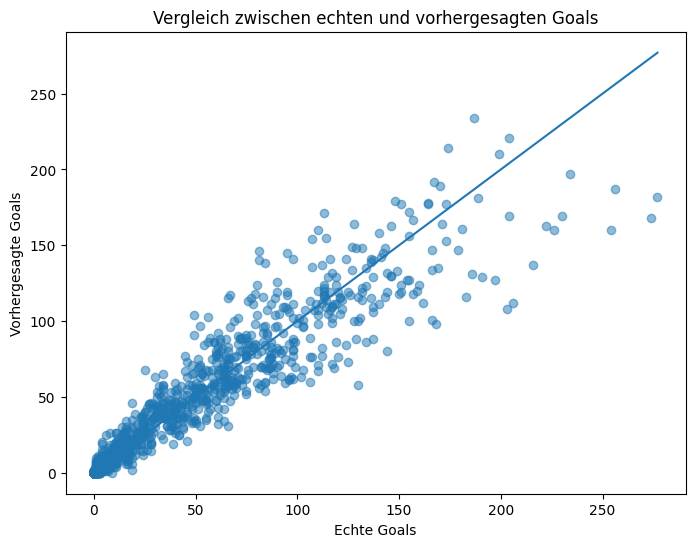

In [9]:
# Grafik: echte Goals gegen vorhergesagte Goals
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rounded, alpha=0.5)
plt.xlabel("Echte Goals")
plt.ylabel("Vorhergesagte Goals")
plt.title("Vergleich zwischen echten und vorhergesagten Goals")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.show()

## 7. Manuelle Überprüfung der Vorhersagen

Bei der manuellen Kontrolle wirken viele Vorhersagen plausibel, weil Spieler mit vielen Spielen, vielen Assists und vielen Fehlwürfen oft auch höhere Torwerte erhalten. Bei sehr tiefen oder sehr hohen Torzahlen können die Abweichungen grösser sein. Das ist nachvollziehbar, weil aussergewöhnlich starke Spieler oder Spezialisten nicht immer nur durch die ausgewählten Statistiken erklärt werden können. Insgesamt erkennt das Modell aber sinnvolle Zusammenhänge zwischen den vorhandenen Feldern und der Zielvariable **Goals**.

## 8. Eigene Beispiel-Vorhersage

Zum Schluss wird eine eigene Beispielzeile erstellt. Damit wird gezeigt, wie das Modell benutzt werden kann, um für neue Spielerdaten eine Vorhersage zu machen.

In [10]:
# Beispiel für eine eigene Vorhersage
example_player = pd.DataFrame([{
    "Games Played": 30,
    "Missed": 45,
    "Assists": 20,
    "Technical Faults": 15,
    "Steals": 8,
    "Blocks": 3,
    "Yellow Cards": 2,
    "2 Min Exclusion": 4,
    "Red Cards": 0,
    "Blue Cards": 0,
    "Position": "LB",
    "Team": "BHC",
    "Season": "21/22",
    "Tier": "A"
}])

example_prediction = model.predict(example_player)[0]
print(f"Vorhergesagte Goals für den Beispielspieler: {round(example_prediction)}")

Vorhergesagte Goals für den Beispielspieler: 62


## Fazit zu Teil 3

In diesem Notebook wurde der Datensatz korrekt in Trainings- und Testdaten aufgeteilt. Danach wurde ein passender Algorithmus aus `sklearn` ausgewählt, erklärt und trainiert. Das Modell wurde verwendet, um Vorhersagen für Testdaten und für ein eigenes Beispiel zu erstellen. Die manuelle Kontrolle zeigt, dass die Vorhersagen grundsätzlich sinnvoll sind, auch wenn bei extremen Spielern Abweichungen entstehen können.